## Chapter 2, P6: Hands-on Practical: Building a GBM with Python

A simplified GBM for a regression task will be constructed to see the mechanics in action and understand how **simple models iteratively form a powerful and accurate predictor w/ GBMs.**

Our **“weak” learners** will be **shallow decision trees**, specifically the **DecisionTreeRegressor** from Scikit-Learn.

## Setting up the environment

We will generate a simple, non-linear dataset based on a sine wave. This gives us a clear target function to see how well our model learns.

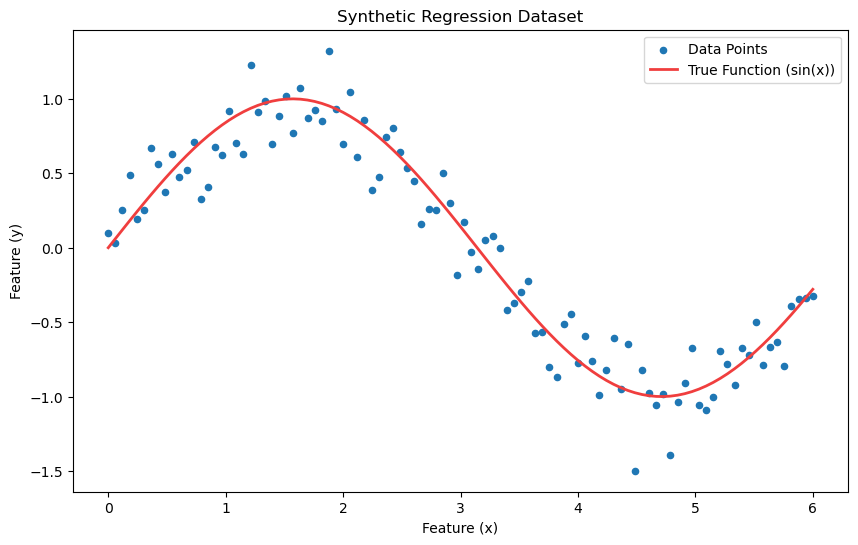

In [1]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

# Generate a synthetic dataset
np.random.seed(42)
X = np.linspace(0, 6, 100)[:, np.newaxis]
y = np.sin(X).ravel() + np.random.normal(0, 0.2, 100)

# Plot the data to see what we're working with
plt.figure(figsize = (10, 6))
plt.scatter(X, y, s = 20, label = 'Data Points')
plt.plot(X, np.sin(X), color = '#f03e3e', linewidth = 2, label = 'True Function (sin(x))')
plt.title('Synthetic Regression Dataset')
plt.xlabel('Feature (x)')
plt.ylabel('Feature (y)')
plt.legend()
plt.show()

## The Gradient Boosting Algorithm from Scratch

We will implement the core logic of GBM for a regression task using Mean Squared Error (MSE) as the loss function. As we learned, the negative gradient of the MSE loss function, $L(y, F) = 1/2(y-F)^2$, is simply the residual, $y-F$

### Step 1: Initialise the Model

The first step is to create an initial prediction. For MSE, the optimal constant prediction that minimises the loss is the mean of the target variable $\bar{y}$

In [4]:
initial_prediction = np.mean(y)

## Step 2: Iterate and Build Trees

For each iteration, we perform three actions:
1. Compute the pseudo-residual (the 'errors' our next tree needs to correct & is trained to predict).
2. Fit a 'weak' learner (a shallow decision tree) to these residuals.
3. Update our overall model's prediction by adding the contribution of this new tree, scaled by a learning rate.

In [ ]:
# Define model hyperparameters
n_estimators = 100
learning_rate = 0.1
max_depth = 1   ## shallow trees as our 'weak' learners

# Store the trees and their current predictions
trees = []
F = np.full(y.shape, initial_prediction)   ## F is our ensemble (prediction) - Initialised all 100 obsv to sample mean

# Run iteration
for _ in range(n_estimators):
    ## 1. Compute pseudo-residual
    residuals = y - F
    
    ## 2. Fit a 'weak' learner to the residuals - learns relationship b/t features & residual errors of current model
    tree = DecisionTreeRegressor(max_depth = max_depth, random_state = 42)
    tree.fit(X, residuals)
    
    ## 3. Update ensemble, adding latest tree's prediction of the residuals to our previous model, scaled by learning rate
    prediction_from_tree = tree.predict(X)
    F = F + learning_rate * prediction_from_tree
    
    ## Store the trained tree
    trees.append(tree)


* `F` represents the cumulative prediction of the ensemble at each stage.
* Each tree is trained on the `residuals`, not on `y`. It learns to predict the error of the current ensemble, adding a small fraction of its prediction back into the ensemble.

## Step 3: Making Predictions

To make a prediction on new data, we follow the same process. We start with the initial prediction (the mean) and then sequentially add the scaled predictions from each tree in our ensemble.

In [ ]:
def predict(X_new, y_new):
    ## Start with the initial constant prediction for all 100 observations
    initial_prediction = np.mean(y_new)
    prediction = np.full(X_new.shape[0], initial_prediction)
    
    ## Make & add the predictions from each 'weak' tree trained (in the ensemble)
    for tree in trees:
        prediction += learning_rate * tree.predict(X_new)
        
    return prediction

## Generate predictions on our original data to see how we did
y_pred = predict(X, y)

## Visualising the Result

The following chart shows the original data points, the true function we were trying to model, our simple initial prediction, and the final, much more sophisticated prediction from our custom GBM.

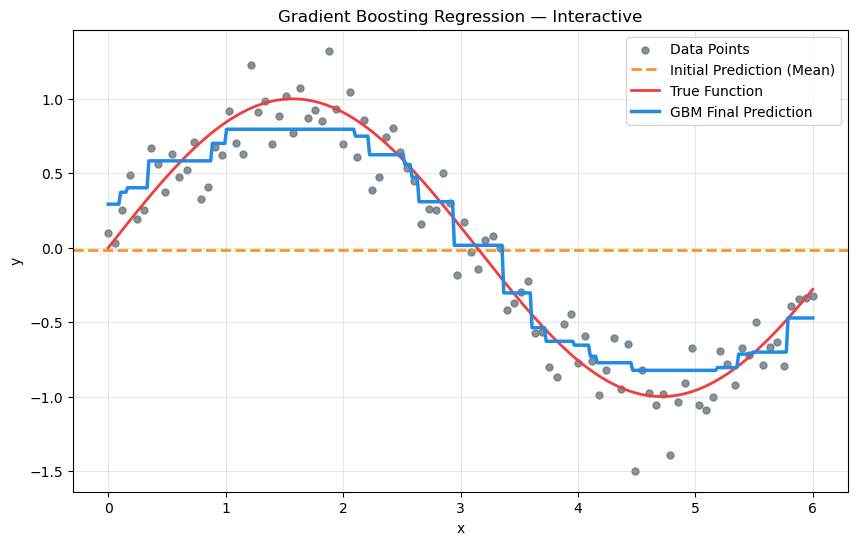

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Generate smooth x for curves
X_plot = np.linspace(0, 6, 400)[:, None]
y_true = np.sin(X_plot).ravel()
y_gbm = predict(X_plot, y_true)

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter data
sc = ax.scatter(X, y, c="#6c757d", s=25, alpha=0.8, label="Data Points")

# Initial prediction
ax.axhline(
    initial_prediction,
    linestyle="--",
    color="#ff922b",
    linewidth=2,
    label="Initial Prediction (Mean)"
)

# True function
ax.plot(
    X_plot,
    y_true,
    color="#f03e3e",
    linewidth=2,
    label="True Function"
)

# GBM prediction
ax.plot(
    X_plot,
    y_gbm,
    color="#228be6",
    linewidth=2.5,
    label="GBM Final Prediction"
)

ax.set_title("Gradient Boosting Regression — Interactive")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

* Model starts with a simple average and iteratively refines its prediction. 
* Each step corrects the errors of the previous one, gradually learning the underlying sinusoidal pattern.
* It achieved this by stringing together 100 very simple decision trees (stumps, in this case), each one correcting the lingering errors from the ones that came before it.

## Summary

While libraries like Scikit-Learn and XGBoost provide highly optimized, feature-rich implementations, the core principle is precisely what was just coded. This hands-on experience provides an invaluable foundation as we move on to using and tuning these powerful, pre-built libraries in the next chapter.  

Below is the entire process, from training to inference, using a GBM.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# 1) Create synthetic datasets
# -----------------------------
np.random.seed(42)

# Training data
X_train = np.linspace(0, 6, 100)[:, np.newaxis]
y_train = np.sin(X).ravel() + np.random.normal(0, 0.2, 100)

# Test data (new points, new noise)
X_test = np.linspace(0.1, 6.1, 100)[:, None]
y_test = np.sin(X_test).ravel() + np.random.normal(0, 0.2, 100)

# ------------------------------------
# 2) Train GBM-from-scratch (regression)
# ------------------------------------
def train_ensemble(X, y, n_estimators = 100, learning_rate = 0.1, max_depth = 1, random_state = 42):
    # Step 1. Start with the initial constant prediction
    initial_prediction = np.mean(y)
    
    # Store the trees and their current predictions
    trees = []
    F = np.full(y.shape, initial_prediction)   ## F is our ensemble (prediction) - Initialised all 100 obsv to sample mean

    # Step 2. Run sequential building of 'weak' learners that error-correct previous trees
    for _ in range(n_estimators):
        # 1) Compute pseudo-residuals (negative gradient for MSE)
        residuals = y - F
        
        ## 2. Fit a 'weak' learner to the residuals - learns relationship b/t features & residual errors of current model
        tree = DecisionTreeRegressor(max_depth = max_depth, random_state = 42)
        tree.fit(X, residuals)
        
        ## 3. Update ensemble prediction, adding latest tree's prediction of the
        ## pseudo-residuals (direction of steepest descent) to our previous model
        prediction_from_tree = tree.predict(X)
        F = F + learning_rate * prediction_from_tree   ## not used prediction - simply to update residuals
        
        # return everything needed for inference
        model = {
            "initial_prediction": initial_prediction,  ## use initial prediction from train set to avoid incorporating info from test set
            "trees": trees,
            "learning_rate": learning_rate
        }
        
        return model

# -----------------------------
# 3) Predict (inference)
# -----------------------------
def make_prediction(model, X_new):
    # Step 3. Make predictions, predicting target (y) on new data
    pred = np.full(X_new.shape[0], model["initial_prediction"], dtype=float)
    
    ## Obtain weighted sum of 100 predictions from each "weak" learner from ensemble
    for tree in model["trees"]:
        pred += model["learning_rate"] * tree.predict(X_new)
    return pred

# -----------------------------
# 4) Train, predict, evaluate
# -----------------------------
model = train_ensemble(X_train, y_train, n_estimators=100, learning_rate=0.1, max_depth=1)

y_pred_train = make_prediction(model, X_train)
y_pred_test  = make_prediction(model, X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test  = mean_squared_error(y_test, y_pred_test)

print(f"Train MSE: {mse_train:.4f}")
print(f"Test  MSE: {mse_test:.4f}")


Train MSE: 0.5076
Test  MSE: 0.5383


* `F` is the **current ensemble prediction on the training data**. It’s **used to compute the pseudo-residuals** (for MSE, the residuals y - F) and is updated each iteration after a new tree is added.  

* The `trained model` for inference is `F0` (the initial constant/mean) + the **list of fitted trees trees** + the `learning_rate`. (trees alone is almost enough, but you need the initial prediction and learning rate too.)  
* The final `prediction` **on new data** is the **sum of the initial prediction plus the learning-rate-scaled outputs of all trees** on this new data. Each tree was trained on the training pseudo-residuals (i.e., what the ensemble is still getting wrong at that stage).